## Исследование устойчивости нейросетевых моделей к методам сжатия: квантование и отбрасывание

### Введение и цель исследования
В современной практике разработки внедрение тяжелых нейросетей на устройства с ограниченными вычислительными ресурсами (мобильные телефоны, IoT, микроконтроллеры) требует сжатия моделей. Однако оптимизация размера и скорости инференса часто имеет скрытую цену.

**Цель проекта:** Исследовать влияние методов сжатия (квантования и прунинга) на качество работы полносвязной нейронной сети, оценивая не только стандартную метрику точности, но и уверенность модели, а также её устойчивость к состязательным атакам.

### Данные
* **Датасет:** Классический `MNIST` (60 000 обучающих и 10 000 тестовых объектов).
* **Признаки:** Изображения $28 \times 28$ пикселей в оттенках серого, векторизованные в 784 входных признака.
* **Предобработка:** Мин-макс нормализация интенсивности пикселей в строгий диапазон $[0, 1]$.

### Модель
* **Архитектура:** Полносвязная многослойная сеть: Вход (784) $\to$ Скрытый слой 1 (256) $\to$ Скрытый слой 2 (128) $\to$ Выход (10 логитов).
* **Активации:** `tanh` (для корректного сравнения с табличным квантованием) и `ReLU` (для проверки эффекта "мертвых нейронов" при прунинге).

### Внутренние искажения (Сжатие модели)
* **Квантование:** 8, 4, 2 бита и Sign-only (1 бит). Оценивается квантование только весов против квантования весов и активаций.
* **Внедрение квантования:** PTQ (Post-Training Quantization) и QAT (Quantization-Aware Training через Straight-Through Estimator).
* **Прунинг (Отбрасывание связей):**
  * По модулю (Magnitude).
  * По первому порядку (Gradient/Sensitivity).
  * По второму порядку (Hessian-based / Optimal Brain Damage).

### Внешние угрозы (Атаки)
* **Методы:** Fast Gradient Sign Method (FGSM) и итеративный Projected Gradient Descent (PGD).
* **Интенсивность:** Радиус возмущения $\varepsilon$ от 0.05 до 0.3 с шагом 0.05.

### Оцениваемые метрики
* **Точность:** Clean Accuracy (на исходных данных) и Robust Accuracy (в условиях состязательного шума).
* **Уверенность модели:** Запас логитов (Margin) $m(x)$, Индекс разреженности границ (MSI) и Хрупкость худшего класса (Worst-Class Drop).
* **Эффективность:** Эффективность сжатия бита (BSE).

### Технологии
`Python`, `NumPy` (базовая математика и архитектура сети), `scikit-learn` (данные), `Matplotlib` + `Seaborn` (визуализация метрик и распределений).

In [1]:
import copy
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

sns.set_theme(style='darkgrid', palette='bright')
%config InlineBackend.figure_format = 'retina'

SEED = 451
np.random.seed(SEED)

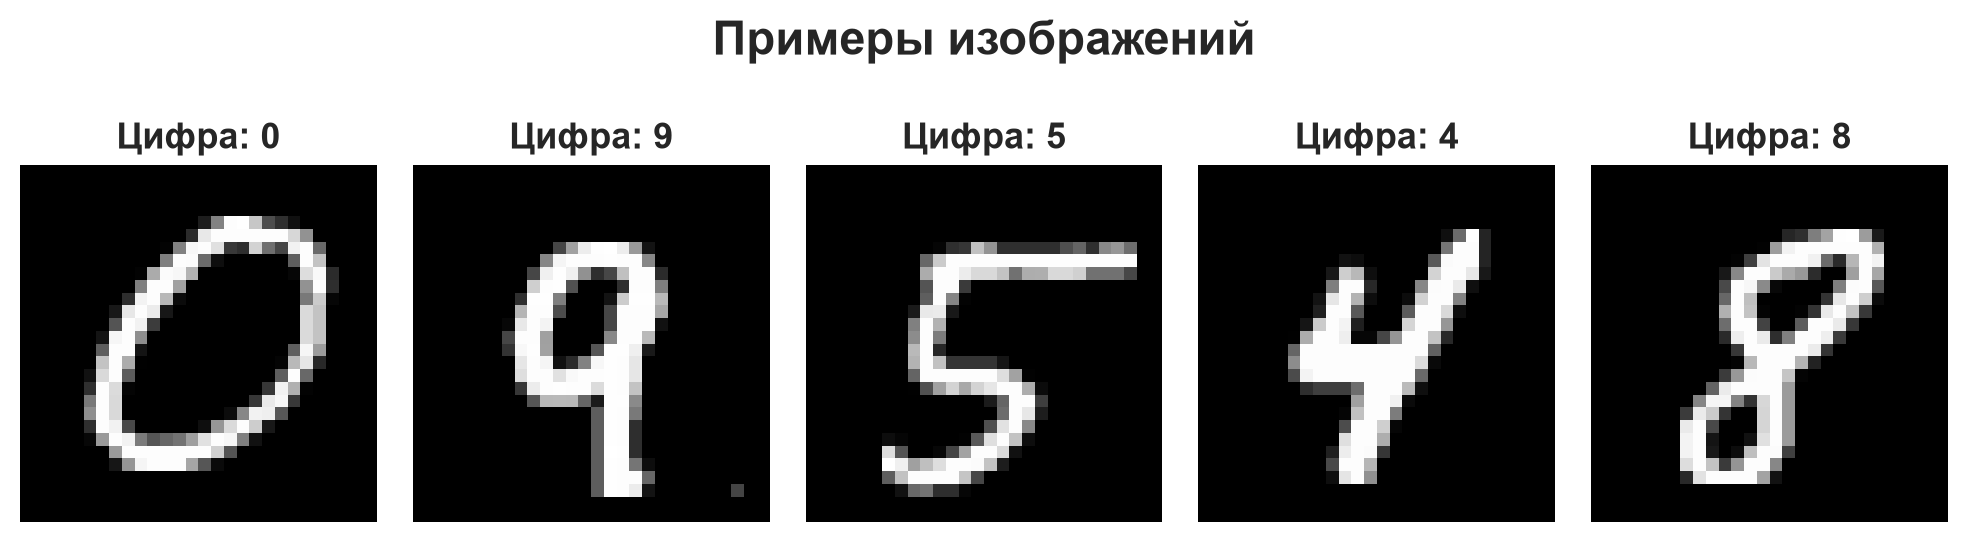

In [2]:
# Установка MNIST (при первом запуске занимает примерно 1 минуту)
data = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = data.data, data.target.astype(np.uint8)

# мин-макс нормализация в [0, 1]
X = X / 255.0

# Берем 60 000 обучающих объектов
X_train, X_test_temp, y_train, y_test_temp = train_test_split(
    X, y, test_size=10000, random_state=SEED, stratify=y
)
# 5 000 на тест и 5 000 на нужды оптимизации (валидация + калибровка)
X_test, X_val_temp, y_test, y_val_temp = train_test_split(
    X_test_temp, y_test_temp, test_size=5000, random_state=SEED, stratify=y_test_temp
)
# 1 000 на калибровку, остальные 4 000 объектов на валидацию
X_val, X_calib, y_val, y_calib = train_test_split(
    X_val_temp, y_val_temp, test_size=1000, random_state=SEED, stratify=y_val_temp
)

# Выведем несколько примеров изображений цифр из MNIST
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle('Примеры изображений', fontweight='bold', fontsize=17, y=0.97)

np.random.seed(SEED)
t = np.random.randint(1, X.shape[0], 5) 

for i in range(5):
    image_matrix = X[t[i]].reshape(28, 28)
    axes[i].imshow(image_matrix, cmap='gray')
    axes[i].set_title(f"Цифра: {y[t[i]]}", fontweight='bold', fontsize=13)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
def get_quantization(W, bits, asymmetric=False):
    # Квантование Sign-only
    if bits == 1:
        return np.sign(W)
        
    if asymmetric:
        # Мин-макс квантование, подходит для ReLU (минимум - 0)
        qmin = 0
        qmax = (2 ** bits) - 1
        alpha = np.max(W)
        if alpha <= 0: 
            return np.zeros_like(W)
    else:
        # Симметричное квантование, подходит для tanh
        qmin = -(2 ** (bits - 1))
        qmax = (2 ** (bits - 1)) - 1
        alpha = np.max(np.abs(W))
        if alpha == 0: 
            return W
    scale = alpha / qmax
    return scale * np.clip(np.round(W / scale), qmin, qmax)

In [4]:
class BasicModel:
    def __init__(
            self, input_dim=784,
            hidden_dim_1=256, hidden_dim_2=128, 
            num_classes=10, activ_func=np.tanh
        ):
        np.random.seed(SEED)

        self.input_w = np.random.normal(
            scale=2/input_dim, size=(input_dim, hidden_dim_1)
        )
        self.input_b = np.zeros(hidden_dim_1)

        self.hl_w = np.random.normal(
            scale=2/hidden_dim_1, size=(hidden_dim_1, hidden_dim_2)
        )
        self.hl_b = np.zeros(hidden_dim_2)

        self.output_w = np.random.normal(
            scale=2/hidden_dim_2, size=(hidden_dim_2, num_classes)
        )
        self.output_b = np.zeros(num_classes)

        self.num_classes = num_classes
        self.activ_func = activ_func
        self.cache = {}
        # Бинарные маски для отбрасывания (1 - связь есть, 0 - удалена)
        self.masks = {
            'input_w': np.ones_like(self.input_w),
            'hl_w': np.ones_like(self.hl_w),
            'output_w': np.ones_like(self.output_w)
        }
        # Единый конфиг квантования
        self.quant_config = {
            'bits': None,  # 8, 4, 2, 1 или None
            'target': 'weights',  # 'weights' или 'both' (веса + активации)
            'mode': None  # 'PTQ' или 'QAT'
        }

    def _softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)
    
    def _activ_func_deriv(self, A):
        if self.activ_func == np.tanh:
            return 1 - A ** 2
        return (A > 0).astype(float)
    
    def _get_logits(self, X):
        z_1 = X @ self.input_w + self.input_b
        nn_layer_1 = self._quant_act(self.activ_func(z_1))

        z_2 = nn_layer_1 @ self.hl_w + self.hl_b
        nn_layer_2 = self._quant_act(self.activ_func(z_2))

        z_3 = nn_layer_2 @ self.output_w + self.output_b
        return z_3
    
    def _quant_act(self, A):
        if (
            self.quant_config['bits'] is not None
        ) and (
            self.quant_config['target'] == 'both'
        ):
            is_relu = (self.activ_func != np.tanh)
            return get_quantization(A, self.quant_config['bits'], asymmetric=is_relu)
        return A

    def forward_prop(self, X):
        z_1 = X @ self.input_w + self.input_b
        nn_layer_1 = self._quant_act(self.activ_func(z_1))

        z_2 = nn_layer_1 @ self.hl_w + self.hl_b
        nn_layer_2 = self._quant_act(self.activ_func(z_2))

        z_3 = nn_layer_2 @ self.output_w + self.output_b
        nn_prob = self._softmax(z_3)
        self.cache = {
            'X': X, 'nn_layer_1': nn_layer_1,
            'nn_layer_2': nn_layer_2, 'nn_prob': nn_prob
        }
        return nn_prob
    
    def backward_prop(self, y_true):
        X = self.cache['X']
        nn_layer_1 = self.cache['nn_layer_1']
        nn_layer_2 = self.cache['nn_layer_2']
        nn_prob = self.cache['nn_prob']
        N = X.shape[0]

        # y_true -> Y - one-hot матрица
        Y = np.zeros_like(nn_prob)
        Y[np.arange(N), y_true] = 1.0

        # Градиенты выходного слоя (3)
        d_z_3 = (nn_prob - Y) / N
        d_output_w = nn_layer_2.T @ d_z_3
        d_output_b = np.sum(d_z_3, axis=0)

        # Градиенты скрытого слоя (2)
        d_nn_layer_2 = d_z_3 @ self.output_w.T
        d_z_2 = d_nn_layer_2 * self._activ_func_deriv(nn_layer_2)
        d_hl_w = nn_layer_1.T @ d_z_2
        d_hl_b = np.sum(d_z_2, axis=0)

        # Градиенты скрытого слоя (1)
        d_nn_layer_1 = d_z_2 @ self.hl_w.T
        d_z_1 = d_nn_layer_1 * self._activ_func_deriv(nn_layer_1)
        d_input_w = X.T @ d_z_1
        d_input_b = np.sum(d_z_1, axis=0)

        return {
            'input_w': d_input_w, 'input_b': d_input_b,
            'hl_w': d_hl_w, 'hl_b': d_hl_b,
            'output_w': d_output_w, 'output_b': d_output_b
        }
    
    def compute_metrics(self, X, y_true):
        logits = self._get_logits(X)
        pred_classes = np.argmax(logits, axis=1)
        N = X.shape[0]

        # Accuracy
        accuracy = np.mean(pred_classes == y_true)
        # Запас логитов (Margin)
        correct_logits = logits[np.arange(N), y_true]
        mask_logits = logits.copy()
        mask_logits[np.arange(N), y_true] = -np.inf
        max_wrong_logits = np.max(mask_logits, axis=1)
        margins = correct_logits - max_wrong_logits
        median_margin = np.median(margins)
        # 10%-й квантиль для поиска уязвимых объектов
        q10_margin = np.quantile(margins, 0.1) 
        # Индекс разреженности границ (MSI): процент объектов в зоне 0 < m(x) < 0.5
        msi = np.mean((margins > 0) & (margins < 0.5)) * 100
        # Локальная точность по каждому из 10 классов
        class_accuracies = {}
        for c in range(self.num_classes):
            class_mask = (y_true == c)
            if np.sum(class_mask) > 0:
                class_accuracies[c] = np.mean(pred_classes[class_mask] == y_true[class_mask])
            else:
                class_accuracies[c] = 0.0
        
        return {
            'accuracy': accuracy,
            'margin': median_margin,
            'q10_margin': q10_margin,
            'msi': msi,
            'class_accuracies': class_accuracies
        }

    def fit(self, X, y, batch_size=100, lr=0.1, max_epochs=100):
        N = X.shape[0]

        for epoch in range(max_epochs):
            # Перемешивание выборки в начале каждой эпохи
            ind = np.arange(N)
            np.random.shuffle(ind)
            X_shf = X[ind]
            y_shf = y[ind]

            for i in range(0, N, batch_size):
                X_batch = X_shf[i : i+batch_size]
                y_batch = y_shf[i : i+batch_size]
                
                # QAT симулирует квантование весов во время обучения
                if (
                    self.quant_config['mode'] == 'QAT'
                ) and (
                    self.quant_config['bits'] is not None
                ):
                    orig_w1 = self.input_w.copy()
                    orig_w2 = self.hl_w.copy()
                    orig_w3 = self.output_w.copy()
                    self.input_w = get_quantization(self.input_w, self.quant_config['bits'])
                    self.hl_w = get_quantization(self.hl_w, self.quant_config['bits'])
                    self.output_w = get_quantization(self.output_w, self.quant_config['bits'])
                
                # Прямой проход
                self.forward_prop(X_batch)
                # Обратный проход
                grad = self.backward_prop(y_batch)

                # Если был включен QAT: Возвращаем float-копии назад, чтобы обновить их градиентом (STE)
                if (
                    self.quant_config['mode'] == 'QAT'
                ) and (
                    self.quant_config['bits'] is not None
                ):
                    self.input_w, self.hl_w, self.output_w = orig_w1, orig_w2, orig_w3
                
                # Обновление параметров (Градиентный спуск)
                self.input_w -= lr * grad['input_w']
                self.input_b -= lr * grad['input_b']
                self.hl_w -= lr * grad['hl_w']
                self.hl_b -= lr * grad['hl_b']
                self.output_w -= lr * grad['output_w']
                self.output_b -= lr * grad['output_b']

                # Принудительное удержание отбрасывания
                self.input_w *= self.masks['input_w']
                self.hl_w *= self.masks['hl_w']
                self.output_w *= self.masks['output_w']

            # Промежуточные результаты 
            metrics = self.compute_metrics(X, y)
            print(
                f"Эпоха {epoch+1:02d}/{max_epochs} | " +
                f"Accuracy: {metrics['accuracy']:.4f} | " +
                f"MSI: {metrics['msi']:.2f}% | " +
                f"Запас логитов: {metrics['margin']:.3f}"
            )

    def predict(self, X):
        logits = self._get_logits(X)
        return np.argmax(logits, axis=1)

In [5]:
def apply_quantization(model, bits=4, target='weights', mode='PTQ'):
    q_model = copy.deepcopy(model)
    q_model.quant_config = {'bits': bits, 'target': target, 'mode': mode}
    
    if mode == 'PTQ':
        # Перезаписываем веса
        q_model.input_w = get_quantization(q_model.input_w, bits)
        q_model.hl_w = get_quantization(q_model.hl_w, bits)
        q_model.output_w = get_quantization(q_model.output_w, bits)
        q_model.quant_config['mode'] = None
        
    return q_model

def apply_pruning(model, pruning_type='magnitude', ratio=0.3, X_calib=None, y_calib=None):
    """
    Типы отбрасывания: 
    - 'magnitude': по значению веса
    - 'gradient': по первому порядку |W * grad|
    - 'hessian': Optimal Brain Damage 0.5 * W^2 * grad^2
    """
    pruned_model = copy.deepcopy(model)
    w_names = ['input_w', 'hl_w', 'output_w']
    accumulated_grad = {name: np.zeros_like(getattr(pruned_model, name)) for name in w_names}
    accumulated_hess = {name: np.zeros_like(getattr(pruned_model, name)) for name in w_names}
    
    if pruning_type in ['gradient', 'hessian']:
        if X_calib is None or y_calib is None:
            raise ValueError(
                "Для градиентных методов отбрасывания нужны X_calib и y_calib!"
            )
        num_samples = X_calib.shape[0]
        for idx in range(num_samples):
            X_sample = X_calib[idx : idx + 1]
            y_sample = y_calib[idx : idx + 1]
            
            pruned_model.forward_prop(X_sample)
            grad_sample = pruned_model.backward_prop(y_sample)
            
            for name in w_names:
                # Для первого порядка копируем/копим обычный градиент
                accumulated_grad[name] += grad_sample[name]
                # Для Гессиана копим КВАДРАТЫ градиентов каждого объекта отдельно
                accumulated_hess[name] += grad_sample[name] ** 2
        
        # Усредняем по размеру калибровочной выборки
        for name in w_names:
            accumulated_grad[name] /= num_samples
            accumulated_hess[name] /= num_samples

    for name in w_names:
        W = getattr(pruned_model, name)
        # Расчет карт важности весов
        if pruning_type == 'magnitude':
            score = np.abs(W)
        elif pruning_type == 'gradient':
            score = np.abs(W * accumulated_grad[name])
        elif pruning_type == 'hessian':
            # 0.5 * H_ii * W^2
            score = 0.5 * accumulated_hess[name] * (W ** 2)
            
        # Находим глобальный порог для слоя по квантилю
        threshold = np.quantile(score, ratio)
        mask = (score >= threshold).astype(float)
        # Отбрасываем
        pruned_model.masks[name] = mask
        setattr(pruned_model, name, W * mask)
        
    return pruned_model

In [ ]:
def model_size(model):
    """
    Вычисляет занимаемую память моделью
    """
    w_names = ['input_w', 'hl_w', 'output_w']
    b_names = ['input_b', 'hl_b', 'output_b']

    # Извлекаем конфигурации квантования
    quant_config = getattr(model, 'quant_config', {}) or {}
    # Извлекаем маски прунинга
    masks = getattr(model, 'masks', {}) or {}

    # Общее кол-во параметров сети (включая сдвиги)
    total_params = sum(getattr(model, name).size for name in (w_names + b_names))
    # Кол-во численно ненулевых параметров
    nonzero_params = sum(np.count_nonzero(getattr(model, name)) for name in (w_names + b_names))

    # Разрядность квантования весов (по умолчанию 32 бита)
    w_bits = quant_config.get('bits') if quant_config.get('bits') else 32
    
    # Сдвиги всегда остаются 32-битными плотными векторами
    total_b_count = sum(getattr(model, name).size for name in b_names)

    # Вычисляем кол-во весов, которые мы храним
    stored_w_count = 0
    for name in w_names:
        weight_matrix = getattr(model, name)
        if name in masks:
            stored_w_count += np.count_nonzero(masks[name])
        else:
            stored_w_count += weight_matrix.size

    # Итоговый размер в битах
    memory_bits = int(stored_w_count * w_bits + total_b_count * 32)
    memory_bytes = memory_bits / 8

    # Базовый размер float32 модели для расчета сжатия
    baseline_bits = total_params * 32
    compression_ratio = baseline_bits / memory_bits if memory_bits > 0 else 1.0

    return {
        "total_params": total_params,
        "nonzero_params": nonzero_params,
        "memory_bits": memory_bits,
        "memory_bytes": memory_bytes,
        "compression_ratio": compression_ratio
    } 

In [7]:
def generate_advers_examples(model, X, y_true, attack_config):
    """Генератор состязательных примеров методом FGSM или PGD"""
    if (not attack_config) or (attack_config.get('type') == 'none'):
        return X
        
    attack_type = attack_config.get('type', 'FGSM').upper()
    eps = attack_config.get('eps', 0.1)
    N = X.shape[0]
    
    def get_gradient(X):
        nn_prob = model.forward_prop(X)
        Y = np.zeros_like(nn_prob)
        Y[np.arange(N), y_true] = 1.0
        
        d_z_3 = (nn_prob - Y) / N
        d_nn_layer_2 = d_z_3 @ model.output_w.T
        d_z_2 = d_nn_layer_2 * model._activ_func_deriv(model.cache['nn_layer_2'])
        d_nn_layer_1 = d_z_2 @ model.hl_w.T
        d_z_1 = d_nn_layer_1 * model._activ_func_deriv(model.cache['nn_layer_1'])
        return d_z_1 @ model.input_w.T

    if attack_type == 'FGSM':
        dX = get_gradient(X)
        X_nois = X + eps * np.sign(dX)
        return np.clip(X_nois, 0.0, 1.0)
        
    elif attack_type == 'PGD':
        alpha = attack_config.get('alpha', 0.01)
        iters = attack_config.get('iters', 10)
        X_nois = X.copy()
        for t in range(iters):
            dX = get_gradient(X_nois)
            X_nois = X_nois + alpha * np.sign(dX)
            X_nois = np.clip(X_nois, X - eps, X + eps)
            X_nois = np.clip(X_nois, 0.0, 1.0)
        return X_nois
        
    return X

In [8]:
def evaluate_model(model, X, y, attack_config=None, baseline_metrics=None):
    """
    Комплексная валидация модели. 
    Рассчитывает абсолютные метрики качества, геометрию границ и состязательную устойчивость.
    """
    N = X.shape[0]
    num_classes = model.num_classes
    
    # Метрики на чистых данных
    logits = model._get_logits(X)
    pred_classes = np.argmax(logits, axis=1)
    accuracy = np.mean(pred_classes == y)
    
    # Поклассовая точность на чистых данных
    clean_class_accs = np.zeros(num_classes)
    for c in range(num_classes):
        mask = (y == c)
        if np.sum(mask) > 0:
            clean_class_accs[c] = np.mean(pred_classes[mask] == c)

    # Расчет чистых запас уверенности
    correct_logits = logits[np.arange(N), y]
    mask_logits = logits.copy()
    mask_logits[np.arange(N), y] = -np.inf
    max_wrong_logits = np.max(mask_logits, axis=1)
    clean_margins = correct_logits - max_wrong_logits
    
    median_margin = np.median(clean_margins)
    margin_q10 = np.quantile(clean_margins, 0.1)
    msi = np.mean((clean_margins > 0) & (clean_margins < 0.5)) * 100
    
    # Метрики устойчивости
    if attack_config and attack_config.get('type') != 'none':
        # Генерируем состязательный датасет
        X_adv = generate_advers_examples(model, X, y, attack_config)
        adv_logits = model._get_logits(X_adv)
        adv_preds = np.argmax(adv_logits, axis=1)
        adv_accuracy = np.mean(adv_preds == y)
        
        # Поклассовая точность под атакой
        adv_class_accs = np.zeros(num_classes)
        for c in range(num_classes):
            mask = (y == c)
            if np.sum(mask) > 0:
                adv_class_accs[c] = np.mean(adv_preds[mask] == c)
        
        # Хрупкость худшего класса под атакой 
        worst_class_adv_drop = np.max(clean_class_accs - adv_class_accs)
        
        # Запасы устойчивости при атаке
        adv_correct_logits = adv_logits[np.arange(N), y]
        adv_mask_logits = adv_logits.copy()
        adv_mask_logits[np.arange(N), y] = -np.inf
        adv_margins = adv_correct_logits - np.max(adv_mask_logits, axis=1)
        median_adv_margins = np.median(adv_margins)
        adv_margin_q10 = np.quantile(adv_margins, 0.1)
    else:
        adv_accuracy = accuracy
        worst_class_adv_drop = 0.0
        median_adv_margins = median_margin
        adv_margin_q10 = margin_q10
        adv_class_accs = clean_class_accs.copy()
    
    # Метрки сжатия
    size_metrics = model_size(model)
    
    # Вычисляем деградацию от сжатия
    if baseline_metrics:
        # Падение худшего класса из-за компрессии
        worst_class_compression_drop = np.max(baseline_metrics['clean_class_accs'] - clean_class_accs)
        # BSE: нормализованное отношение изменения точности к сжатию памяти
        delta_acc = baseline_metrics['accuracy'] - accuracy
        saved_bits = baseline_metrics['memory_bits'] - size_metrics['memory_bits']
        # Эффективность: сколько точности (в %) мы теряем на каждый мегабит освобожденной памяти
        # Чем меньше этот индекс, тем эффективнее сжатие
        bse = (delta_acc * 100) / (saved_bits / 1e6) if saved_bits > 0 else 0.0
    else:
        worst_class_compression_drop = 0.0
        bse = 0.0

    return {
        # Базовые
        "accuracy": accuracy,
        "adv_accuracy": adv_accuracy,

        # Геометрия границ
        "median_margin": median_margin,
        "margin_q10": margin_q10,
        "median_adv_margins": median_adv_margins,
        "adv_margin_q10": adv_margin_q10,
        "msi": msi,

        # Поклассовый анализ
        "worst_class_adv_drop": worst_class_adv_drop,
        "worst_class_compression_drop": worst_class_compression_drop,

        # Размер и эффективность
        "memory_bits": size_metrics['memory_bits'],
        "compression_ratio": size_metrics['compression_ratio'],
        "bse": bse,

        # Сырые массивы
        "clean_class_accs": clean_class_accs
    }

In [9]:
def compression_pipeline(base_model, config, datasets):
    """Строго последовательный пайплайн трансформации архитектуры модели"""
    X_train, y_train, X_val, y_val, X_calib, y_calib = datasets
    model = copy.deepcopy(base_model)
    
    # Модификация функции активации
    if config.get('activation'):
        act = config['activation'].lower()
        if act == 'relu':
            model.activ_func = lambda x: np.maximum(0, x)
        elif act == 'tanh':
            model.activ_func = np.tanh

    # Отбрасывание
    if config.get('pruning'):
        p_cfg = config['pruning']
        model = apply_pruning(
            model, pruning_type=p_cfg['type'], 
            ratio=p_cfg['ratio'], X_calib=X_calib, y_calib=y_calib
        )
        if p_cfg.get('fine_tune_epochs', 0) > 0:
            model.fit(X_train, y_train, max_epochs=p_cfg['fine_tune_epochs'])

    # Квантование
    if config.get('quantization'):
        q_cfg = config['quantization']
        model = apply_quantization(
            model, bits=q_cfg['bits'], 
            target=q_cfg['target'], mode=q_cfg['mode']
        )
        if (q_cfg['mode'] == 'QAT') and (q_cfg.get('fine_tune_epochs', 0) > 0):
            model.fit(X_train, y_train, max_epochs=q_cfg['fine_tune_epochs'])

            model.input_w = get_quantization(model.input_w, q_cfg['bits'])
            model.hl_w = get_quantization(model.hl_w, q_cfg['bits'])
            model.output_w = get_quantization(model.output_w, q_cfg['bits'])
            
    return model

In [10]:
def run_experiment(base_model, config, datasets, baseline_metrics):
    """Запускает пайплайн сжатия и формирует плоский словарь результатов"""
    X_train, y_train, X_val, y_val, X_calib, y_calib = datasets
    # Оптимизируем модель
    compressed_model = compression_pipeline(base_model, config, datasets)
    # Оцениваем по всем фронтам на валидации
    metrics = evaluate_model(
        compressed_model, 
        X_val, y_val, 
        attack_config=config.get('attack'),
        baseline_metrics=baseline_metrics
    )
    # Превращаем вложенный конфиг в плоские колонки для таблицы Pandas
    flat_report = {
        "activation": config.get("activation", "tanh"),
        "bits": config.get("quantization", {}).get("bits", 32),
        "quant_target": config.get("quantization", {}).get("target", "none"),
        "quant_mode": config.get("quantization", {}).get("mode", "none"),
        "pruning_type": config.get("pruning", {}).get("type", "none"),
        "pruning_ratio": config.get("pruning", {}).get("ratio", 0.0),
        "ft_epochs": config.get("pruning", {}).get("fine_tune_epochs", 0) + config.get("quantization", {}).get("fine_tune_epochs", 0),
        "attack_type": config.get("attack", {}).get("type", "none"),
        "attack_eps": config.get("attack", {}).get("eps", 0.0)
    }
    # Объединяем конфигурационные параметры с вычисленными метриками
    metrics.pop('clean_class_accs', None)
    flat_report.update(metrics)
    return flat_report

In [11]:
def generate_experiments_grid(config):
    """
    Автоматически генерирует сетку базовых конфигураций:
    - 16 моделей с квантованием (4 разряда x 2 таргета x 2 режима)
    - 12 моделей с прунингом (4 коэффициента x 3 режима)
    """
    grid_configs = []
    activation = config['activation']

    # Общие параметры атак
    default_attack = {"type": "FGSM", "eps": 0.1}
    
    # 16 базовых моделей квантования
    bits_list = [8, 4, 2, 1]
    target_list = ["weights", "both"]
    # Настройки квантования: QAT (с дообучением) и PTQ (пост-обучающее)
    quant_setups = [
        {"mode": "QAT", "fine_tune_epochs": 2},
        {"mode": "PTQ"}
    ]
    for bits, target, q_setup in itertools.product(
        bits_list, target_list, quant_setups
    ):
        cfg = {
            "activation": activation,
            "quantization": {
                "bits": bits,
                "target": target,
                "mode": q_setup["mode"]
            },
            "attack": default_attack
        }
        # Добавляем эпохи дообучения, если это QAT
        if "fine_tune_epochs" in q_setup:
            cfg["quantization"]["fine_tune_epochs"] = q_setup["fine_tune_epochs"]
            
        grid_configs.append(cfg)
        
    # 12 базовых моделей отбрасывания
    pruning_ratios = [0.3, 0.5, 0.7, 0.9]
    # Настройки прунинга
    pruning_setups = [
        {"type": "magnitude", "fine_tune_epochs": 0},
        {"type": "gradient", "fine_tune_epochs": 0},
        {"type": "hessian", "fine_tune_epochs": 0}
    ]
    for ratio, p_setup in itertools.product(pruning_ratios, pruning_setups):
        cfg = {
            "activation": activation,
            "pruning": {
                "type": p_setup["type"],
                "ratio": ratio,
                "fine_tune_epochs": p_setup["fine_tune_epochs"]
            },
            "attack": default_attack
        }
        grid_configs.append(cfg)
        
    return grid_configs

def print_experiment(idx, total, config, is_baseline=False):
    """
    Красиво выводит в консоль текущий прогресс эксперимента.
    """
    print('\n'+"="*80)
    if is_baseline:
        print(f"Обучение базовой модели (Активация: {config['activation'].upper()})")
    else:
        details = []
        if "pruning" in config:
            p = config["pruning"]
            details.append(f"Отбрасывание: {p['type']} (удалено {p['ratio']*100:.0f}% связей + {p['fine_tune_epochs']} эпох дообучения)")
        if "quantization" in config:
            q = config["quantization"]
            ft_str = f", {q['fine_tune_epochs']} эпох дообучения" if "fine_tune_epochs" in q else ""
            details.append(f"Квантование: {q['bits']}bit ({q['mode']}{ft_str})")
        if "attack" in config and config["attack"]["type"] != "none":
            details.append(f"Атака: {config['attack']['type']} (eps={config['attack']['eps']})")
            
        details_str = " | ".join(details) if details else "Без модификаций"
        print(f"Эксперимент {idx}/{total} | Активация: {config['activation'].upper()} | {details_str}")

In [12]:
# Базовая функция активации
baseline_cfg = {"activation": "tanh"} # Или relu

if baseline_cfg["activation"] == "tanh":
    activ_function = np.tanh
else:
    activ_function = lambda x: np.maximum(0, x)

# Сборка всех конфигураций для тестирования
# Автоматическая сетка (28 моделей)
experiment_configs = generate_experiments_grid(baseline_cfg)

# Дополнительные эксперименты (вводятся вручную)
manual_configs = [
    # Например: 
    # отбрасывание по модулю веса 80% (+3 эпохи дообучения) +
    # + квантование весов в 2 бита (+2 эпохи дообучения). 
    # И атака PGD с eps=0.1
    # {
    #     "activation": "tanh", 
    #     "pruning": {"type": "magnitude", "ratio": 0.8, "fine_tune_epochs": 3}, 
    #     "quantization": {"bits": 2, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
    #     "attack": {"type": "PGD", "eps": 0.1}
    # }
]

# Объединяем сетку и ручные тесты
experiment_configs.extend(manual_configs)
total_runs = len(experiment_configs)

# Наборы данных
datasets = (X_train, y_train, X_val, y_val, X_calib, y_calib)
results = []

# Обучение и оценка базовой модели
print_experiment(0, total_runs, baseline_cfg, is_baseline=True)
baseline_model = BasicModel(activ_func=activ_function)
baseline_model.fit(X_train, y_train, max_epochs=15)
baseline_metrics = evaluate_model(baseline_model, X_val, y_val, attack_config={"type": "none"})
baseline_flat_report = {
    "activation": baseline_cfg["activation"],
    "bits": 32,
    "quant_target": "none",
    "quant_mode": "none",
    "pruning_type": "none",
    "pruning_ratio": 0.0,
    "ft_epochs": 0,
    "attack_type": "none",
    "attack_eps": 0.0
}
# Распаковываем значения метрик
for metric_key, meta in baseline_metrics.items():
    if metric_key not in ["clean_class_accs"]:
        baseline_flat_report[metric_key] = meta
# Сохраняем базовую модель как первый эксперимент
results.append(baseline_flat_report)

# Запуск конвейера экспериментов по сетке
print(f"Базовая модель обучена. Запуск серии сжатий и атак (всего экспериментов: {total_runs})\n")
for idx, cfg in enumerate(experiment_configs, start=1):
    print_experiment(idx, total_runs, cfg)
    # Запускаем пайплайн сжатия и оценки
    report = run_experiment(
        base_model=baseline_model, 
        config=cfg, 
        datasets=datasets, 
        baseline_metrics=baseline_metrics
    )
    results.append(report)

# Формирование итогового датафрейма
df = pd.DataFrame(results)
print("Все эксперименты завершены успешно! Таблица результатов записана.")


Обучение базовой модели (Активация: TANH)
Эпоха 01/15 | Accuracy: 0.8633 | MSI: 4.72% | Запас логитов: 2.348
Эпоха 02/15 | Accuracy: 0.9032 | MSI: 2.98% | Запас логитов: 3.392
Эпоха 03/15 | Accuracy: 0.9268 | MSI: 2.09% | Запас логитов: 4.104
Эпоха 04/15 | Accuracy: 0.9391 | MSI: 1.75% | Запас логитов: 4.490
Эпоха 05/15 | Accuracy: 0.9515 | MSI: 1.48% | Запас логитов: 4.943
Эпоха 06/15 | Accuracy: 0.9580 | MSI: 1.30% | Запас логитов: 5.374
Эпоха 07/15 | Accuracy: 0.9653 | MSI: 1.22% | Запас логитов: 5.587
Эпоха 08/15 | Accuracy: 0.9698 | MSI: 0.95% | Запас логитов: 5.759
Эпоха 09/15 | Accuracy: 0.9729 | MSI: 0.86% | Запас логитов: 6.052
Эпоха 10/15 | Accuracy: 0.9751 | MSI: 0.87% | Запас логитов: 6.199
Эпоха 11/15 | Accuracy: 0.9769 | MSI: 0.76% | Запас логитов: 6.591
Эпоха 12/15 | Accuracy: 0.9791 | MSI: 0.73% | Запас логитов: 6.640
Эпоха 13/15 | Accuracy: 0.9820 | MSI: 0.63% | Запас логитов: 7.013
Эпоха 14/15 | Accuracy: 0.9827 | MSI: 0.60% | Запас логитов: 7.090
Эпоха 15/15 | Accur

In [13]:
display(df)

,activation,bits,quant_target,quant_mode,pruning_type,pruning_ratio,ft_epochs,attack_type,attack_eps,accuracy,...,median_margin,margin_q10,median_adv_margins,adv_margin_q10,msi,worst_class_adv_drop,worst_class_compression_drop,memory_bits,compression_ratio,bse
0,tanh,32,none,none,none,0.0,0,none,0.0,0.96800,...,7.274078,3.070731,7.274078,3.070731,0.750,0.000000,0.000000,7524672,1.000000,0.000000
1,tanh,8,weights,QAT,none,0.0,2,FGSM,0.1,0.96900,...,7.318421,3.083705,-3.562702,-9.108523,0.775,0.988889,0.008310,1890624,3.979994,-0.017749
2,tanh,8,weights,PTQ,none,0.0,0,FGSM,0.1,0.96775,...,7.275548,3.085722,-3.119105,-8.319163,0.675,0.986667,0.002451,1890624,3.979994,0.004437
3,tanh,8,both,QAT,none,0.0,2,FGSM,0.1,0.97000,...,7.579612,3.290687,-3.465723,-8.859900,0.650,0.984444,0.005540,1890624,3.979994,-0.035498
4,tanh,8,both,PTQ,none,0.0,0,FGSM,0.1,0.96775,...,7.269700,3.090032,-3.107502,-8.322903,0.700,0.986667,0.002513,1890624,3.979994,0.004437
5,tanh,4,weights,QAT,none,0.0,2,FGSM,0.1,0.96775,...,7.377105,3.052865,-2.116647,-7.770462,0.700,0.975556,0.012821,951616,7.907257,0.003803
6,tanh,4,weights,PTQ,none,0.0,0,FGSM,0.1,0.96350,...,6.593785,2.342225,-2.025019,-7.114278,0.850,0.975556,0.031175,951616,7.907257,0.068461
7,tanh,4,both,QAT,none,0.0,2,FGSM,0.1,0.96750,...,7.600768,2.946034,-1.637451,-7.165121,0.700,0.971111,0.017588,951616,7.907257,0.007607
8,tanh,4,both,PTQ,none,0.0,0,FGSM,0.1,0.96400,...,6.593180,2.347046,-2.070243,-7.266132,0.900,0.971111,0.023981,951616,7.907257,0.060854
9,tanh,2,weights,QAT,none,0.0,2,FGSM,0.1,0.76750,...,2.738636,-2.210803,-0.124995,-5.054988,4.200,0.438725,0.534626,482112,15.607726,2.846976


In [14]:
# Столбцы таблицы
EXPERIMENT_TABLE_COLUMNS = {
    # Параметры модели
    "activation": {
        "name_ru": "Активация",
        "full_name": "Функция активации скрытых слоев",
        "unit": "строка",
        "desc": "Тип функции активации, используемой в скрытых слоях нейросети (например, tanh, relu)."
    },
    "bits": {
        "name_ru": "Разрядность (бит)",
        "full_name": "Разрядность квантования весов",
        "unit": "бит",
        "desc": "Целевая глубина квантования весов. 32 бита соответствуют исходной модели без сжатия."
    },
    "quant_target": {
        "name_ru": "Объект квантования",
        "full_name": "Целевые параметры для квантования",
        "unit": "категория",
        "desc": "Какие именно параметры подвергаются квантованию (веса, активации или 'none')."
    },
    "quant_mode": {
        "name_ru": "Протокол квантования",
        "full_name": "Алгоритм квантования весов",
        "unit": "категория",
        "desc": "Стратегия округления весов (PTQ - квантование после обучения, QAT - обучение с учетом квантования или 'none')."
    },
    "pruning_type": {
        "name_ru": "Тип отбрасывания",
        "full_name": "Стратегия прореживания весов",
        "unit": "категория",
        "desc": "Метод зануления слабых весов (magnitude - по абсолютной величине, gradient, hessian, или 'none')."
    },
    "pruning_ratio": {
        "name_ru": "% отбрасывания",
        "full_name": "Доля удаляемых весов (Sparsity Ratio)",
        "unit": "доля",
        "desc": "Целевой процент зануляемых весов в слоях. 0.8 - удалено 80% весов."
    },
    "ft_epochs": {
        "name_ru": "Эпох дообучения",
        "full_name": "Суммарное кол-во эпох дообучения",
        "unit": "число",
        "desc": "Общее количество эпох, потраченных на восстановление точности после отбрасывания и во время QAT."
    },
    "attack_type": {
        "name_ru": "Тип атаки",
        "full_name": "Метод генерации состязательного шума",
        "unit": "категория",
        "desc": "Алгоритм, которым генерировались искажения для проверки устойчивости (FGSM, PGD или 'none')."
    },
    "attack_eps": {
        "name_ru": "Сила атаки (epsilon)",
        "full_name": "Амплитуда состязательного шума",
        "unit": "доля",
        "desc": "Максимальное допустимое изменение значения каждого пикселя при проведении атаки."
    },

    # Базовые метрики
    "accuracy": {
        "name_ru": "Точность",
        "full_name": "Точность классификации на чистых данных (Clean Accuracy)",
        "unit": "доля",
        "formula": "Accuracy = \\frac{1}{N} \\sum_{i=1}^N [y_i = \\hat{y}_i]",
        "desc": "Доля правильных ответов модели на оригинальном (неискаженном атакой) наборе данных."
    },
    "adv_accuracy": {
        "name_ru": "Точность при атаке",
        "full_name": "Точность под состязательной атакой (Robust Accuracy)",
        "unit": "доля",
        "formula": "Robust\\ Accuracy = \\frac{1}{N} \\sum_{i=1}^N [y_i = \\hat{y}_{adv, i}]",
        "desc": "Доля верных предсказаний модели в условиях наложенного шума (FGSM или PGD) заданной интенсивности epsilon."
    },
    
    # Геометрия границ
    "median_margin": {
        "name_ru": "Медианный запас логитов",
        "full_name": "Медиана распределения запаса логитов (Median Margin)",
        "unit": "безразмерно",
        "formula": "Median(z_y(x) - \\max_{r \\neq y} z_r(x))",
        "desc": "Медианная разность между логитом истинного класса и сильнейшим ложным альтернативным классом. Показывает базовую уверенность модели."
    },
    "margin_q10": {
        "name_ru": "Запас логитов (квантиль 10%)",
        "full_name": "10%-й квантиль распределения запаса логитов на чистых данных",
        "unit": "безразмерно",
        "formula": "Quantile(m(x), 0.1)",
        "desc": "Запас уверенности для 10% наименее уверенных объектов. Показывает, насколько уязвимы граничные примеры на чистом датасете."
    },
    "median_adv_margins": {
        "name_ru": "Медианный запас логитов при атаке",
        "full_name": "Медиана распределения запаса логитов под состязательной атакой",
        "unit": "безразмерно",
        "formula": "Median(z_y(x_{adv}) - \\max_{r \\neq y} z_r(x_{adv}))",
        "desc": "Медианный запас уверенности на всем атакованном датасете. Если значение становится меньше нуля, это означает, что атака смогла успешно переубедить более половины объектов."
    },
    "adv_margin_q10": {
        "name_ru": "Запас логитов при атаке (квантиль 10%)",
        "full_name": "10%-й квантиль распределения запаса логитов под состязательной атакой",
        "unit": "безразмерно",
        "formula": "Quantile(m_{adv}(x), 0.1)",
        "desc": "Показывает величину границы уязвимости. Глубокие отрицательные значения указывают на то, что на 10% самых уязвимых объектов атака не просто побеждает, а уводит предсказания модели далеко в зону ложных классов с высокой уверенностью."
    },
    "msi": {
        "name_ru": "Индекс разреженности границ (MSI)",
        "full_name": "Индекс разреженности границ - Margin Sparsity Index",
        "unit": "%",
        "formula": "MSI = \\frac{1}{N} \\sum_{i=1}^N [0 < m(x_i) < 0.5] \\times 100%",
        "desc": "Процент корректно классифицированных объектов, находящихся в критической зоне слабой уверенности у разделяющей границы (запас от 0 до 0.5). Меньше - лучше."
    },
    
    # Поклассовый анализ
    "worst_class_adv_drop": {
        "name_ru": "Деградация худшего класса от атаки",
        "full_name": "Максимальное поклассовое падение точности под атакой",
        "unit": "доля",
        "formula": "\\max_{c} (Acc_{clean, c} - Acc_{adv, c})",
        "desc": "Показывает наибольшее падение точности среди отдельных классов при применении атаки. Помогает выявить критически уязвимые классы-мишени."
    },
    "worst_class_compression_drop": {
        "name_ru": "Деградация худшего класса от сжатия",
        "full_name": "Максимальное поклассовое падение точности из-за сжатия весов",
        "unit": "доля",
        "formula": "\\max_{c} (Acc_{baseline, c} - Acc_{compressed, c})",
        "desc": "Показывает, точность какого класса сильнее всего упала из-за отбрасывания или квантования по сравнению с несжатой моделью."
    },
    
    # Размер и эффективность
    "memory_bits": {
        "name_ru": "Физический размер",
        "full_name": "Расчетный объем памяти для хранения весов",
        "unit": "бит",
        "formula": "W_{nonzero} \\times bits + B \\times 32",
        "desc": "Размер параметров модели с учетом отбрасывания и квантования."
    },
    "compression_ratio": {
        "name_ru": "Коэффициент сжатия",
        "full_name": "Коэффициент уменьшения физического размера модели",
        "unit": "раз",
        "formula": "Ratio = Size_{float32} / Size_{compressed}",
        "desc": "Показывает, во сколько раз уменьшился объем памяти, занимаемый моделью, по сравнению с базовой 32-битной версией."
    },
    "bse": {
        "name_ru": "Эффективность сжатия границ (BSE)",
        "full_name": "Boundary Sparsity Efficiency Index",
        "unit": "% / Мбит",
        "formula": "BSE = \\frac{\\Delta Accuracy \\times 100}{\\Delta Size \\ / \\ 10^6}",
        "desc": "Показывает процент падения точности на каждый мегабит освобожденной памяти. Чем меньше значение, тем более эффективно прошло сжатие."
    },
}

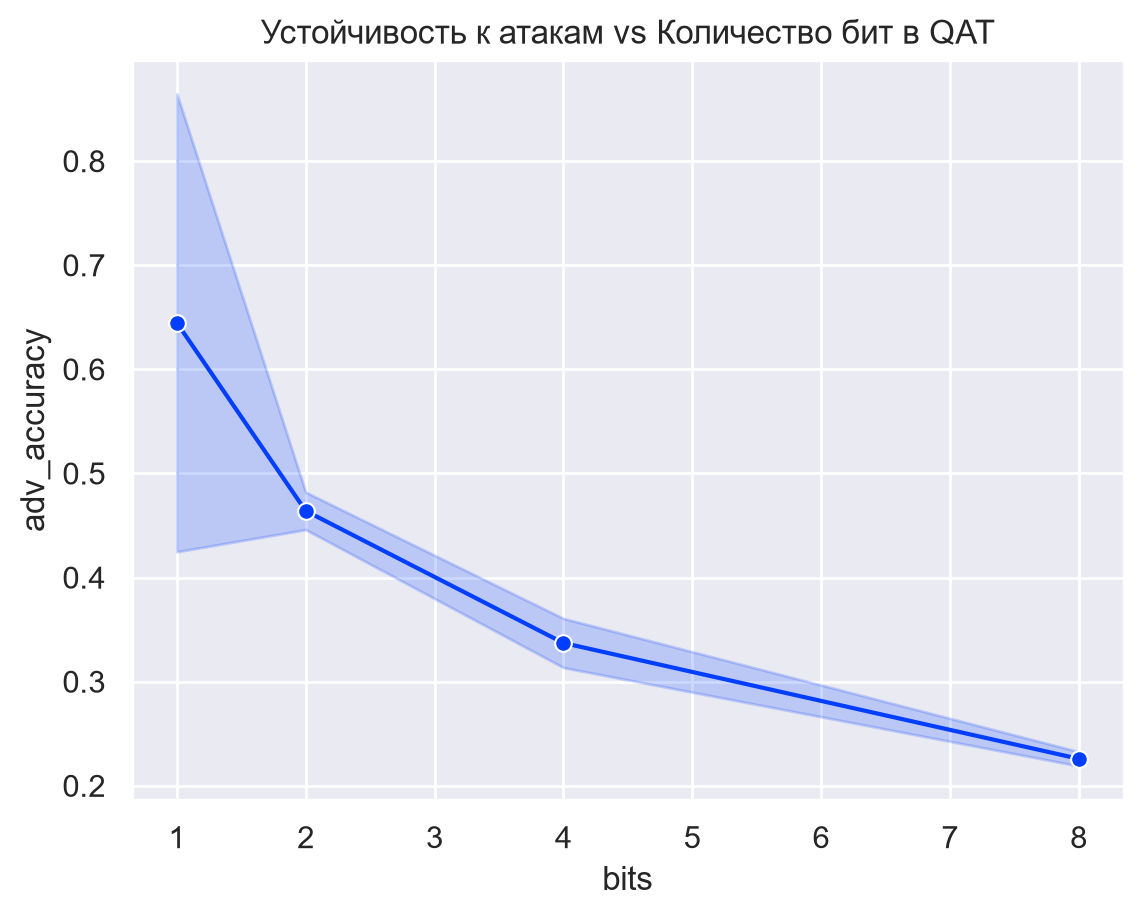

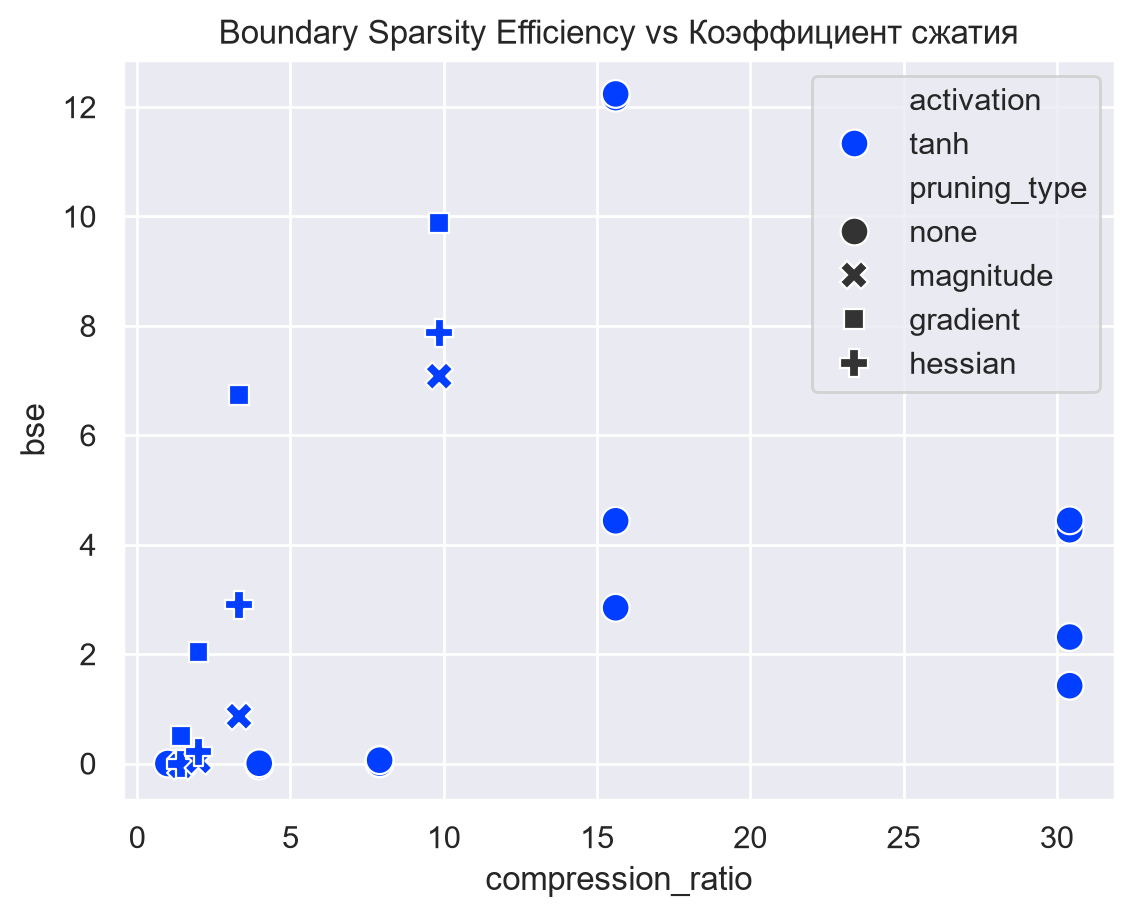

In [15]:
# График: Как разрядность квантования влияет на устойчивость (Adv Accuracy) в режиме QAT
sns.lineplot(data=df[df['quant_mode']=='QAT'], x='bits', y='adv_accuracy', marker='o')
plt.title("Устойчивость к атакам vs Количество бит в QAT")
plt.show()

# График: Эффективность границ (BSE) в зависимости от коэффициента сжатия
sns.scatterplot(data=df, x='compression_ratio', y='bse', hue='activation', style='pruning_type', s=100)
plt.title("Boundary Sparsity Efficiency vs Коэффициент сжатия")
plt.show()